# Synthetic Data Generation for K-Means Clustering


The implementation and code references presented in this are based on examples provided in the official **scikit-learn** documentation Source [\[1\]](https://scikit-learn.org/stable/datasets/sample_generators.html#sample-generators).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_circles, make_moons

In [2]:
# Creates a 2D scatter plot showing clustered data points (colored by label) and their corresponding centroids (black stars)

def plot_graph(X, y, z, title=""):
    '''
    X : data points (n_samples, 2)
    y : cluster labels
    z : cluster centroids
    title : plot title
    '''
    plt.figure(figsize=(8,8))
    plt.scatter(X[:,0], X[:,1], s=50, alpha=0.5, c=y, cmap='tab10', label='Cluster Points')
    plt.scatter(z[:,0], z[:,1], c='black', marker='*', s=100, label='Centroid')
    plt.title(f"Cluster with Original Label and Centers: {title}", fontsize=12)
    plt.xlabel("Feature 1", fontsize=10)
    plt.ylabel("Feature 2", fontsize=10)
    plt.xlim(0,55)
    plt.ylim(0,55)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## X1~X_aniso :  Anisotropic Blob Generation



1. Generate synthetic 2D clusters (blobs) using `make_blobs`.  
2. Apply a transformation to make clusters anisotropic.  
3. Shift one cluster slightly to vary positions.  
4. Adjust cluster centers accordingly.  
5. Plot the generated clusters along with their centers using `plot_graph`.  



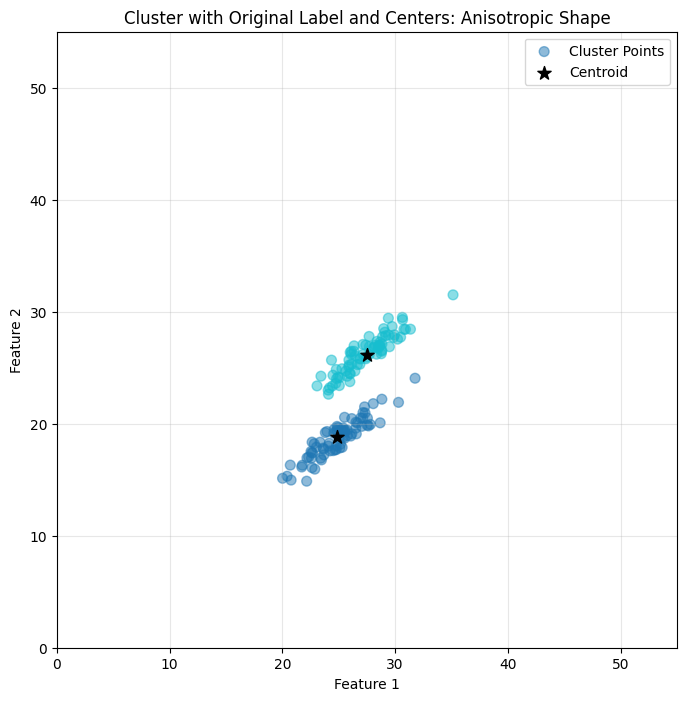

In [3]:
X1, y1, z1 = make_blobs(n_samples=150, n_features=2, centers=2, cluster_std=[3,3], center_box=(20,45), random_state=21, shuffle=True, return_centers=True)

transformation = [[0.4, 0.5], [0.6, 0.3]]

X_aniso = np.dot(X1, transformation)
X_aniso[y1 == 1] += [0, 1]
z_aniso = np.dot(z1, transformation)
z_aniso[1] += [0, 1]
plot_graph(X_aniso,y1,z_aniso, "Anisotropic Shape")

## X2 : Blob Shape Generation


1. Generate synthetic 2D clusters (blobs) using `make_blobs` with specified standard deviations and centers.  
2. Plot the generated clusters along with their centers using `plot_graph`.  


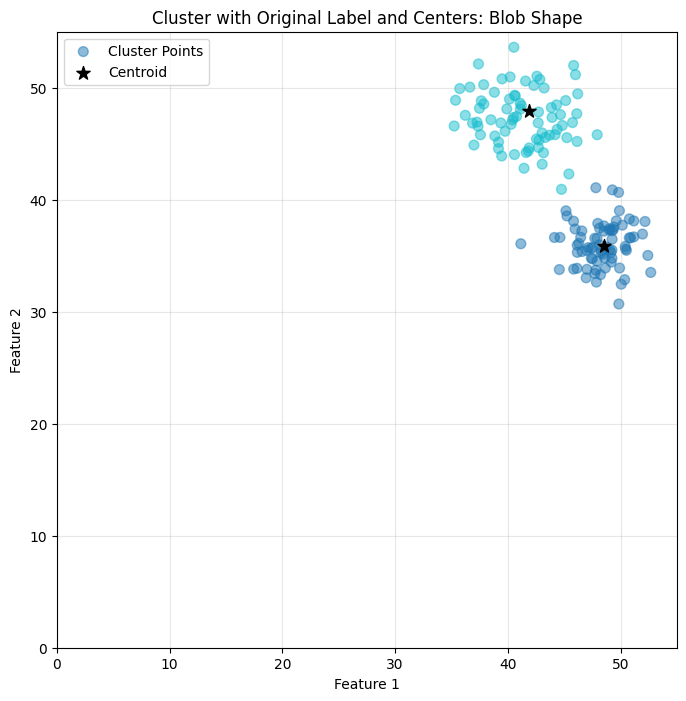

In [4]:
X2, y2, z2 = make_blobs(n_samples=150, n_features=2, centers=2, cluster_std=[2,3], center_box=(35, 55),random_state=51, shuffle=True, return_centers=True)

plot_graph(X2,y2,z2, "Blob Shape")

## X3 : Moon Shape Generation


1. Generate a synthetic 2D two-moons dataset using `make_moons`.  
2. Scale and shift the data to desired position.  
3. Compute cluster centers for each moon.  
4. Slightly adjust the points and centers to increase separation.  
5. Plot the resulting dataset with its centers using `plot_graph`.  


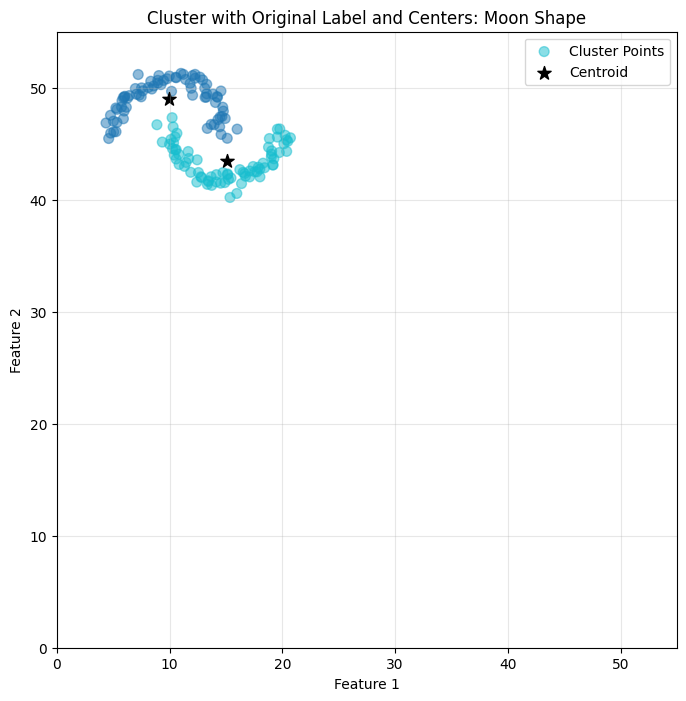

In [5]:
X3, y3 = make_moons(n_samples=150, noise=0.1, random_state=0)
X_moon = X3 * 5 + [10, 45]
z3 = np.array([X_moon[y3 == z].mean(axis=0) for z in np.unique(y3) ])
X_moon[y3 == 0, 1] += 1 
X_moon[y3 == 1, 1] -= 1
z3[0, 1] += 1
z3[1, 1] -= 1

plot_graph(X_moon,y3,z3, "Moon Shape")

## X4 : Circle Shape Generation

1. Generate a synthetic 2D concentric circles dataset using `make_circles`.  
2. Scale and shift the data to the desired position.  
3. Compute cluster centers for each circle.  
4. Plot the dataset along with the centers using `plot_graph`.


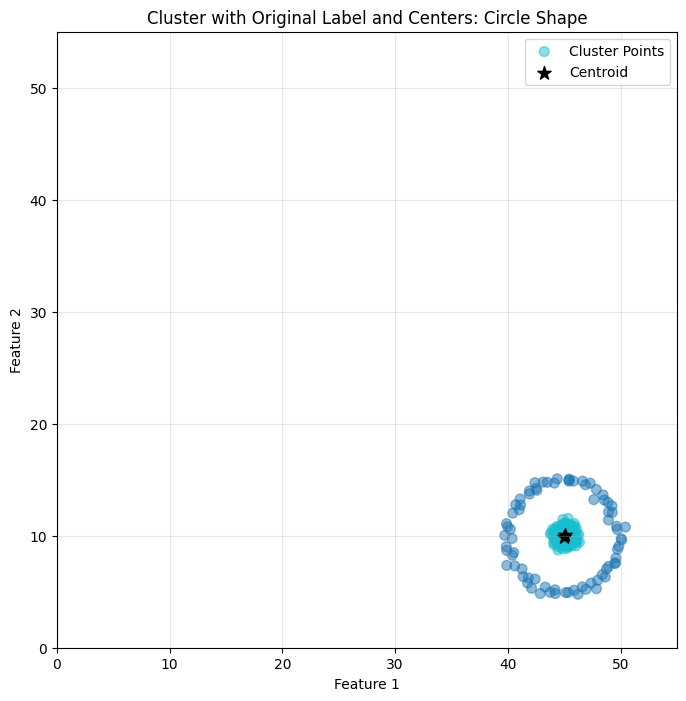

In [6]:
X4, y4 = make_circles(n_samples=150, noise=0.05, factor=0.2 ,random_state=0)
X_cir  = X4 * 5 + [45, 10]
z4 = np.array([X_cir[y4 == z].mean(axis=0) for z in np.unique(y4) ])

plot_graph(X_cir,y4,z4, "Circle Shape")

## X5: Square Shape Generation

1. Generate 2D random points using a fixed random seed.  
2. Scale and shift the points to form a square-shaped distribution.  
3. Compute the center of the square cluster.  
4. Plot the dataset along with the cluster center using `plot_graph`.


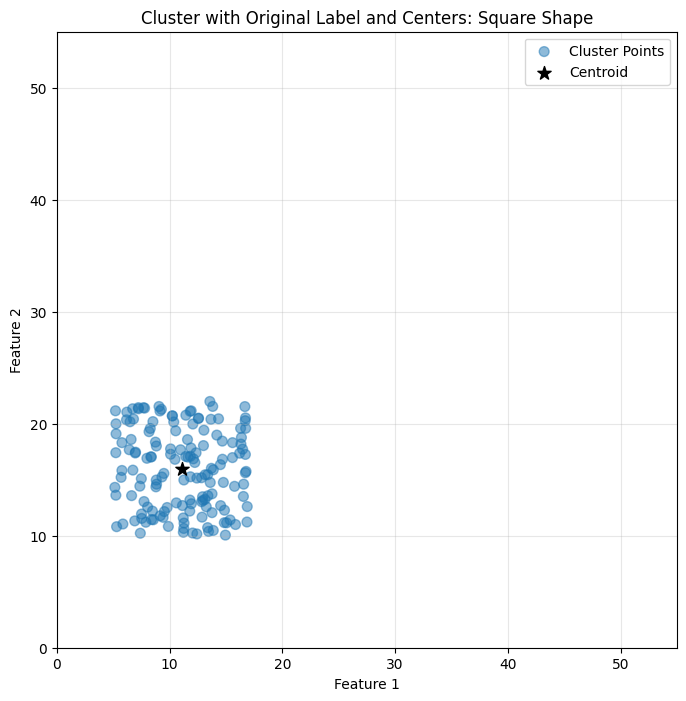

In [7]:
rng = np.random.RandomState(0)
X5 = rng.rand(150, 2)
y5 = np.full(150,8)
X5_square = X5*12 + [5, 10]
z5 = np.array([X5_square[y5 == z].mean(axis=0) for z in np.unique(y5) ])

plot_graph(X5_square,y5,z5, "Square Shape")

### Combining All Datasets 

- Reshape cluster labels using `.reshape(-1,1)` to make them column vectors and adjust values to avoid overlap.  
- Combine all datasets and labels into single arrays.  
- Create a DataFrame and save the combined dataset as `k_means_data.csv`.  
- Create a DataFrame for cluster centroids and save as `k_means_centroid.csv`.



In [8]:
y1 = y1.reshape(-1,1)
y2 = (y2 + 2).reshape(-1, 1)
y3 = (y3 + 4).reshape(-1, 1)
y4 = (y4 + 6).reshape(-1, 1)
y5 = y5.reshape(-1, 1)

X_combined = np.vstack((X_aniso,X2, X_moon, X_cir, X5_square))
y_combined = np.vstack((y1,y2, y3 ,y4, y5)).astype(int)
z = np.vstack((z_aniso, z2, z3, z4, z5))

raw_data = np.hstack((X_combined, y_combined))
data = pd.DataFrame(raw_data, columns=["feature1", "feature2", "cluster"])
data["cluster"] = y_combined.ravel().astype(int) 
data.to_csv("Data/k_means_data.csv", index=False)

centroids_df = pd.DataFrame(z, columns=["X1", "X2"])
centroids_df["cluster"] = range(1, len(z)+1)  
centroids_df.to_csv("Data/k_means_centroid.csv", index=False)

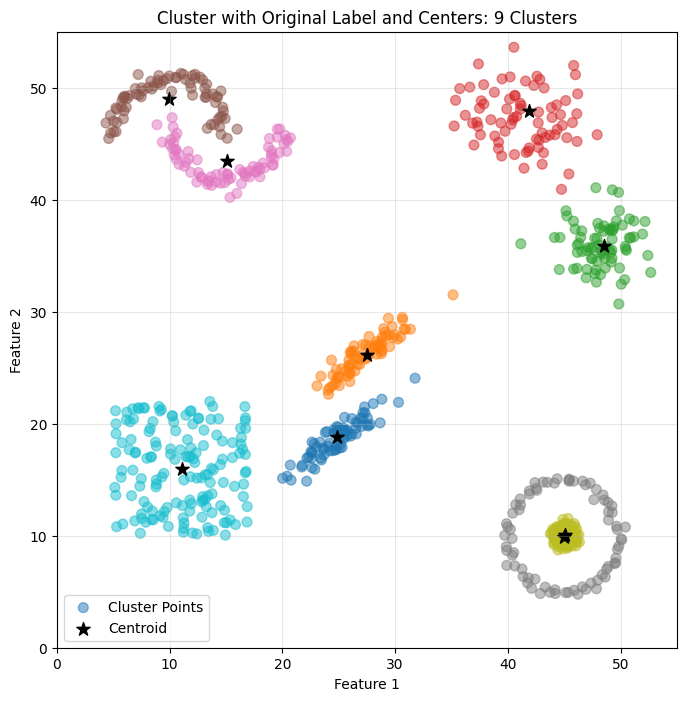

In [9]:
plot_graph(data.values,y_combined,z, "9 Clusters")

## Reference
- [1] [Sample Generators](https://scikit-learn.org/stable/datasets/sample_generators.html#sample-generators)